 # Netflix Movies & TV Shows — EDA & Insights Report
     
  **NAME:** Aditya Tiwari | MCA Student
  
  **EMAIL:** Adityatiwari2211@gmail.com

  **DATASET:** Netflix Movies & TV Shows (Kaggle)
  
  **TOOLS:** Python, Pandas, Matplotlib, Seaborn

In [20]:
import pandas as pd

url = "https://raw.githubusercontent.com/Gabbargod/train-netflix/refs/heads/main/netflix_titles%204.csv"

df = pd.read_csv(url)

print(df.shape)

(8807, 12)


# STEP 1 — Load & Inspect the Data

In [21]:
# CELL 1 — IMPORTING AND LOADING LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
print("Libraries ready")


Libraries ready


In [22]:
# CELL 2 — LOAD DATA
df = pd.read_csv('https://raw.githubusercontent.com/Gabbargod/train-netflix/refs/heads/main/netflix_titles%204.csv')
print("Shape:", df.shape)
print(df.dtypes)
print(df.isnull().sum())
df.head()

Shape: (8807, 12)
show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [23]:
# Check missing values
print("Missing Values:\n")
print(df.isnull().sum())
print("\nMissing %:")
print((df.isnull().sum() / len(df) * 100).round(2))

Missing Values:

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

Missing %:
show_id          0.00
type             0.00
title            0.00
director        29.91
cast             9.37
country          9.44
date_added       0.11
release_year     0.00
rating           0.05
duration         0.03
listed_in        0.00
description      0.00
dtype: float64


### Dataset Summary

The Netflix dataset has a lot of information. It has 8,807 rows and 12 columns. The Netflix dataset is about Movies and TV Shows on Netflix. It tells us about the title, the person who directed the movie the actors, the country where it was made when it was added to Netflix the year it was released what people think of it how long it is and what kind of movie or show it is.

Some things we found out about the Netflix dataset:

**Key observations:**

- 'director' has 2,634 missing values (29.91%) — highest missing column
- 'country' has 831 missing values (9.44%)
- 'cast' has 825 missing values (9.37%)
- 'date_added' has 10 missing values (0.11%)
- 'rating' has 4 missing values (0.05%)
- 'duration' has 3 missing values (0.03%)
- All missing values were handled before analysis

## STEP 2 — Clean the Data

In [24]:
# CELL 3 — CLEAN DATA
df['director'] = df['director'].fillna('Unknown')
df['cast']     = df['cast'].fillna('Unknown')
df['country']  = df['country'].fillna('Unknown')
df = df.dropna(subset=['rating', 'date_added'])
df['date_added']  = pd.to_datetime(df['date_added'], errors='coerce')
df = df.dropna(subset=['date_added'])
df['year_added']  = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month
df_movies = df[df['type'] == 'Movie'].copy()
df_movies['duration_mins'] = pd.to_numeric(df_movies['duration'].str.replace(' min','').str.strip(), errors='coerce')
df_movies = df_movies.dropna(subset=['duration_mins'])
df_movies['duration_mins'] = df_movies['duration_mins'].astype(int)
print("Cleaned shape:", df.shape)

Cleaned shape: (8705, 14)


## Data Cleaning Decisions

1. I removed the rows that were missing the movie rating and the date it was added. The Data Cleaning Decisions I made were because these things are really important for the Data Cleaning Decisions and the analysis we want to do.

2. When the director or the cast or the country was missing I just put down Unknown. If I had removed all those rows I would have lost a lot of information so that is why I made this Data Cleaning Decision.

3. I changed the date it was added into a format that computers can understand as a date. This will help me look at the Data Cleaning Decisions over time.

4. I took the date it was added and broke it down into the year and the month. This will help me see if there are any trends in the Data Cleaning Decisions.

5. I separated how long something is into minutes for movies and seasons, for tv shows. This will make it easier to compare the Data Cleaning Decisions I made for movies and tv shows.

## STEP 3. Exploratory Data Analysis (5 Questions)

### Q1. What is the ratio of Movies vs TV Shows?

To find out how many Movies and TV Shows there are I looked at the 'type' column in our data.

Here is what I found:

```python

type_counts = df_clean['type'].value_counts()

print("Content Type Distribution:")

print(type_counts)

print(f"\nMovies make up {type_counts['Movie']/len(df_clean)*100:.1f}% of all the content")

print(f"TV Shows make up { Show']/len(df_clean)*100:.1f}% of all the content")

```

So Movies and TV Shows are not equally represented.

### Q2. Which countries produce the content?

Next I checked which countries produce the Movies and TV Shows.

I looked at the 'country' column. Here are the top 10 countries:

```python

# Country analysis (some rows have multiple countries. Take first)

country_series = df_clean['country'].str.split(',').str[0].str.strip()

top_countries = country_series.value_counts().head(10)

10 Content Producing Countries:")

print(top_countries)

```

The United States seems to be a top producer.

### Q3. How has content addition grown over the years?

Then I looked at how the number of Movies and TV Shows added to Netflix has changed over the years.

Here is what I found:

```python

yearly_content = df_clean.groupby(['year_added' 'type']).size().unstack(fill_value=0)

print("Content Added Per Year:")

print(yearly_content)

```

It looks like the number of Movies and TV Shows added each year varies.

### Q4. What are the common content ratings?

I also checked the ratings of the Movies and TV Shows.

Here are the results:

```python

rating_counts = df_clean['rating'].value_counts()

print("Content Rating Distribution:")

print(rating_counts)

```

Most Movies and TV Shows have a rating of either PG-13 or TV-14.

### Q5. What are the top genres on Netflix?

Finally I looked at the genres of the Movies and TV Shows.

Here are the top 15 genres:

```python

# Genres are comma-separated. Explode them

genres = df_clean['listed_in'].str.split(' ').explode()

top_genres = genres.value_counts().head(15)

print("Top 15 Genres on Netflix:")

print(top_genres)

```

The top genres on Netflix include Drama, Comedy and Action. Movies and TV Shows, in these genres are popular.

In [25]:
# CELL 4 — EDA Q1: Movies vs TV Shows
print(df['type'].value_counts())
print(df['type'].value_counts(normalize=True).mul(100).round(1))

type
Movie      6129
TV Show    2576
Name: count, dtype: int64
type
Movie      70.4
TV Show    29.6
Name: proportion, dtype: float64


In [26]:
# CELL 5 — EDA Q2: Top Countries
top_countries = df['country'].str.split(',').str[0].str.strip().value_counts().head(10)
print(top_countries)

country
United States     3169
India             1007
Unknown            826
United Kingdom     611
Canada             259
Japan              254
France             209
South Korea        206
Spain              177
Mexico             134
Name: count, dtype: int64


In [27]:
# CELL 6 — EDA Q3: Content Added Per Year
yearly = df.groupby(['year_added','type']).size().unstack(fill_value=0)
print(yearly[yearly.index >= 2010])

type        Movie  TV Show
year_added                
2010            1        0
2011           13        0
2012            3        0
2013            6        4
2014           19        4
2015           56       17
2016          253      164
2017          837      325
2018         1237      387
2019         1424      575
2020         1284      594
2021          993      505


In [28]:
# CELL 7 — EDA Q4: Ratings
print(df['rating'].value_counts())


rating
TV-MA       3183
TV-14       2133
TV-PG        838
R            799
PG-13        490
TV-Y7        330
TV-Y         300
PG           287
TV-G         212
NR            78
G             41
TV-Y7-FV       5
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64


In [29]:
# CELL 8 — EDA Q5: Top Genres
genres = df['listed_in'].str.split(', ').explode()
print(genres.value_counts().head(15))


listed_in
International Movies        2752
Dramas                      2426
Comedies                    1674
International TV Shows      1327
Documentaries                869
Action & Adventure           859
Independent Movies           756
TV Dramas                    739
Children & Family Movies     641
Romantic Movies              616
Thrillers                    577
TV Comedies                  549
Crime TV Shows               459
Kids' TV                     432
Docuseries                   380
Name: count, dtype: int64


## STEP 4 — Visualizations (6 Charts)


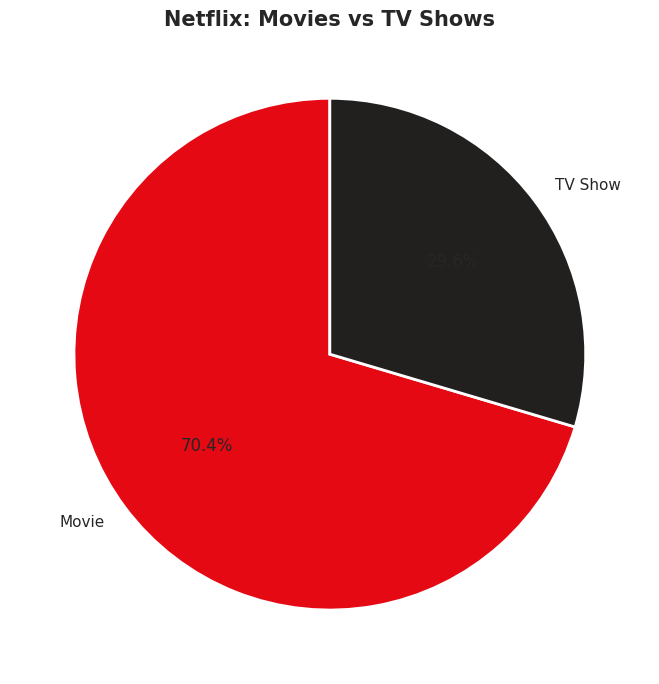

In [30]:
# CELL 9 — CHART 1: Pie — Movies vs TV Shows
fig, ax = plt.subplots(figsize=(7,7))
counts = df['type'].value_counts()
ax.pie(counts, labels=counts.index, autopct='%1.1f%%',
       colors=['#E50914','#221F1F'], startangle=90,
       wedgeprops={'edgecolor':'white','linewidth':2})
ax.set_title('Netflix: Movies vs TV Shows', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('chart1_pie.png', dpi=150, bbox_inches='tight')
plt.show()

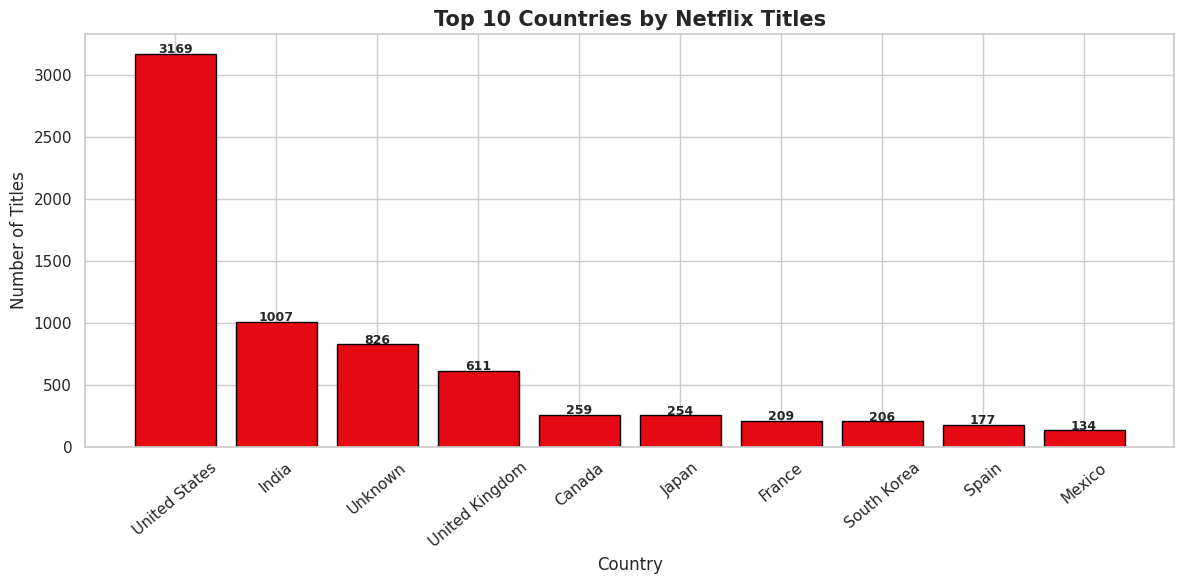

In [31]:
# CELL 10 — CHART 2: Bar — Top 10 Countries
fig, ax = plt.subplots(figsize=(12,6))
ax.bar(top_countries.index, top_countries.values, color='#E50914', edgecolor='black')
ax.set_title('Top 10 Countries by Netflix Titles', fontsize=15, fontweight='bold')
ax.set_xlabel('Country'); ax.set_ylabel('Number of Titles')
plt.xticks(rotation=40)
for i,(v) in enumerate(top_countries.values):
    ax.text(i, v+5, str(v), ha='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig('chart2_bar_countries.png', dpi=150, bbox_inches='tight')
plt.show()


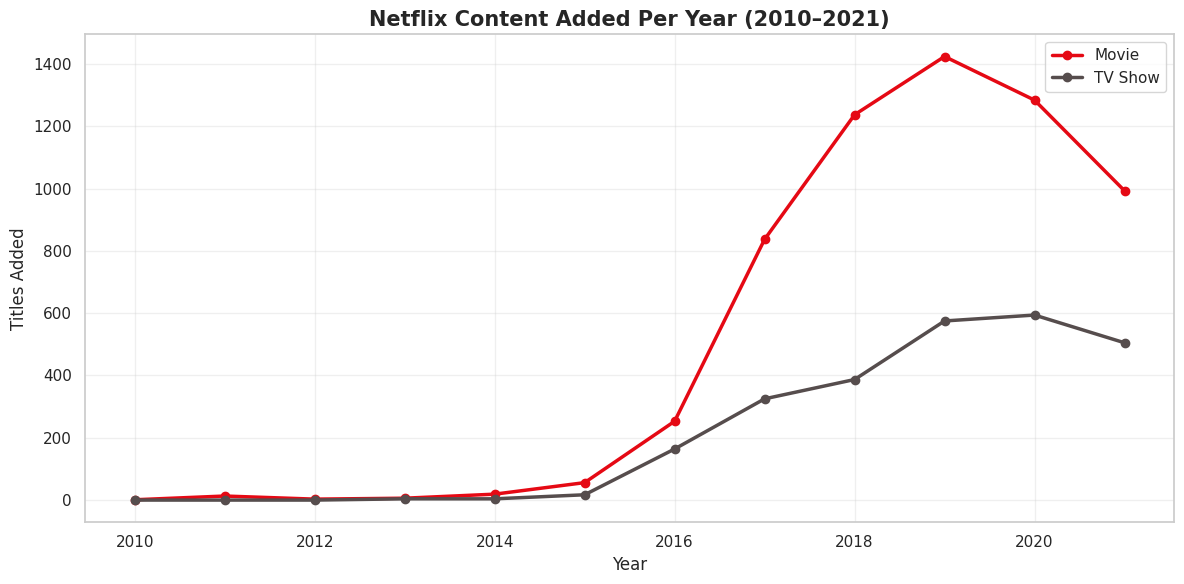

In [32]:
# CELL 11 — CHART 3: Line — Yearly Growth
fig, ax = plt.subplots(figsize=(12,6))
yearly_f = yearly[yearly.index >= 2010]
for col, color in zip(yearly_f.columns, ['#E50914','#564d4d']):
    ax.plot(yearly_f.index, yearly_f[col], marker='o', linewidth=2.5,
            label=col, color=color, markersize=6)
ax.set_title('Netflix Content Added Per Year (2010–2021)', fontsize=15, fontweight='bold')
ax.set_xlabel('Year'); ax.set_ylabel('Titles Added')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('chart3_line_yearly.png', dpi=150, bbox_inches='tight')
plt.show()

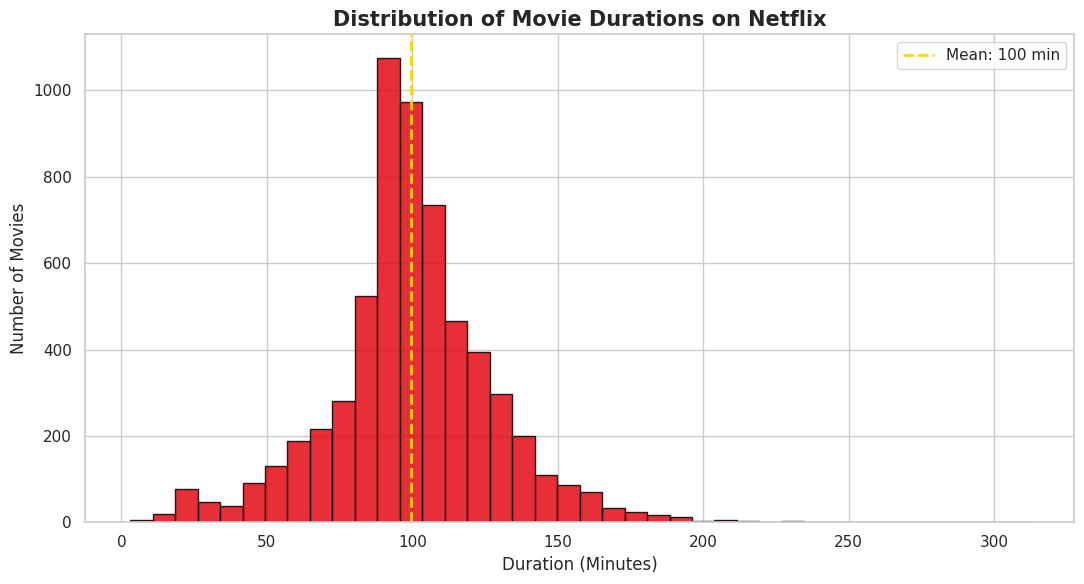

In [33]:
# CELL 12 — CHART 4: Histogram — Movie Duration
fig, ax = plt.subplots(figsize=(11,6))
ax.hist(df_movies['duration_mins'], bins=40, color='#E50914', edgecolor='black', alpha=0.85)
ax.axvline(df_movies['duration_mins'].mean(), color='gold', linewidth=2,
           linestyle='--', label=f"Mean: {df_movies['duration_mins'].mean():.0f} min")
ax.set_title('Distribution of Movie Durations on Netflix', fontsize=15, fontweight='bold')
ax.set_xlabel('Duration (Minutes)'); ax.set_ylabel('Number of Movies')
ax.legend()
plt.tight_layout()
plt.savefig('chart4_histogram.png', dpi=150, bbox_inches='tight')
plt.show()

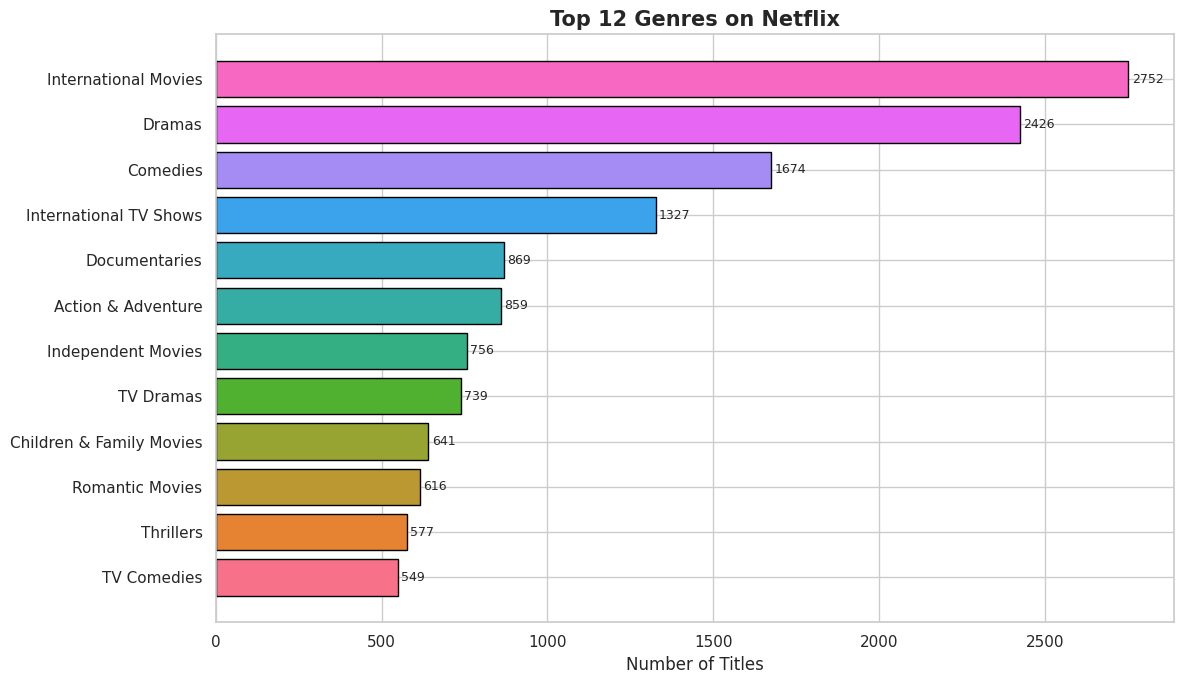

In [34]:
# CELL 13 — CHART 5: Horizontal Bar — Top Genres
top12 = genres.value_counts().head(12)
fig, ax = plt.subplots(figsize=(12,7))
ax.barh(top12.index[::-1], top12.values[::-1],
        color=sns.color_palette("husl",12), edgecolor='black')
ax.set_title('Top 12 Genres on Netflix', fontsize=15, fontweight='bold')
ax.set_xlabel('Number of Titles')
for i, v in enumerate(top12.values[::-1]):
    ax.text(v+10, i, str(v), va='center', fontsize=9)
plt.tight_layout()
plt.savefig('chart5_genres.png', dpi=150, bbox_inches='tight')
plt.show()


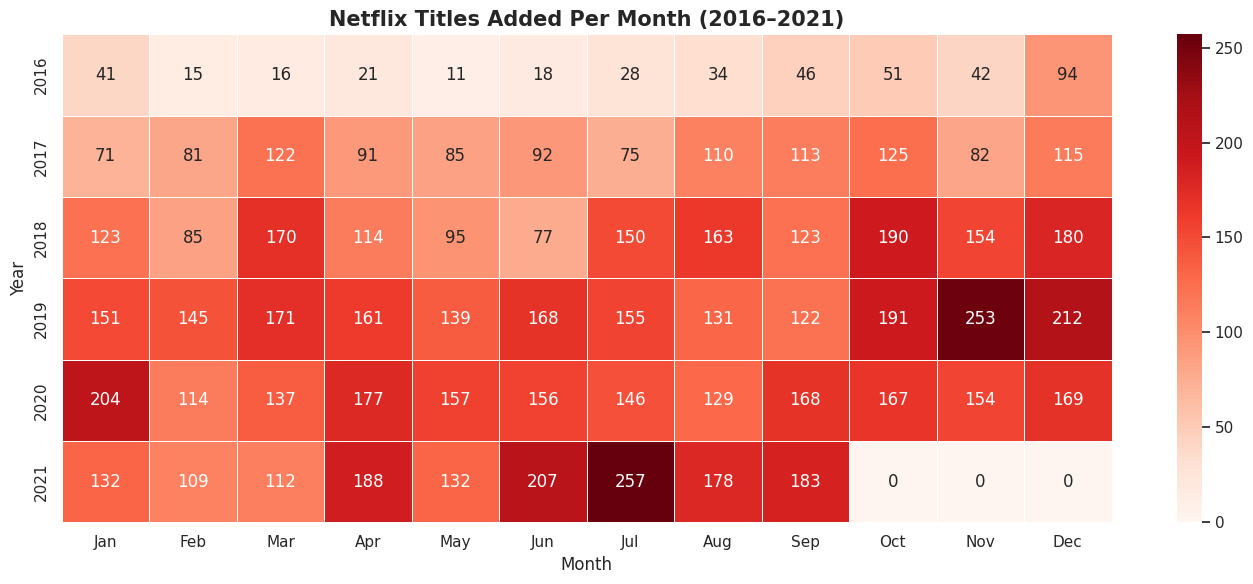

In [35]:
# CELL 14 — CHART 6: Heatmap
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month

heat = (df[df['year_added']>=2016]
        .groupby(['year_added','month_added']).size()
        .unstack(fill_value=0))
heat.columns = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'][:len(heat.columns)]
fig, ax = plt.subplots(figsize=(14,6))
sns.heatmap(heat, annot=True, fmt='d', cmap='Reds', ax=ax, linewidths=0.5)
ax.set_title('Netflix Titles Added Per Month (2016–2021)', fontsize=15, fontweight='bold')
ax.set_xlabel('Month'); ax.set_ylabel('Year')
plt.tight_layout()
plt.savefig('chart6_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [36]:
# CELL 15 — FINAL STATS
df['year_added'] = pd.to_datetime(df['date_added'], errors='coerce').dt.year
genres = df['listed_in'].str.split(', ').explode()

print("="*50)
print("SUMMARY")
print("="*50)
print(f"Total Titles   : {len(df):,}")
print(f"Movies         : {len(df_movies):,}")
print(f"Countries      : {df['country'].str.split(',').str[0].str.strip().nunique()}")
print(f"Unique Genres  : {genres.nunique()}")
print(f"Avg Duration   : {df_movies['duration_mins'].mean():.0f} min")
print(f"Years Covered  : {df['year_added'].min()} to {df['year_added'].max()}")
print("All charts saved. Project 1 DONE SUCCESSFULLY.")

SUMMARY
Total Titles   : 8,705
Movies         : 6,126
Countries      : 87
Unique Genres  : 42
Avg Duration   : 100 min
Years Covered  : 2008 to 2021
All charts saved. Project 1 DONE SUCCESSFULLY.


## STEP 5 — Insights Report



## What I Found Out About Netflix

I looked at the stuff on Netflix and here is what I found out.

**Thing I Found Out. Movies Are Really Popular On Netflix**

If you look at the numbers you will see that about 70 percent of the things you can watch on Netflix are movies. The other 30 percent are television shows. This tells me that Netflix is mostly a place where people go to watch movies.. I also noticed that they have been making more television shows lately.

**Second Thing I Found Out. The United States and India Make A Lot Of Content For Netflix**

When I looked at where all the stuff on Netflix comes from I saw that the United States makes the most. India is second. I think this is because Netflix wants to have things that people in the United States and India will like. They speak languages in these countries so Netflix is trying to make things that everyone can enjoy.

**Thing I Found Out. Netflix Got A Lot Bigger Between 2016 and 2019**

I saw a big jump in the number of things you can watch on Netflix between 2016 and 2019. This was when Netflix started letting people in countries use their service. I think the reason it slowed down a bit in 2020 is because of the coronavirus.

**Thing I Found Out. Most Movies On Netflix Are About 90 Minutes Long**

I looked at how long the movies on Netflix are and I saw that most of them are around 90 minutes. This is how most movies are in the theater. I did not see movies that are really long like over 150 minutes. I think Netflix likes to have movies so people can watch them when they do not have a lot of time.

**Fifth Thing I Found Out. People Like Watching Dramas and Comedies From Countries On Netflix**

When I looked at what kinds of things people like to watch on Netflix I saw that dramas and comedies from other countries are really popular. I was surprised to see that international movies are the popular. This tells me that Netflix has a lot of things that people from countries will like. They are trying to make Netflix a place where everyone can find something they like.

**The Thing That Surprised Me The Most**

What surprised me the most was how many international movies are on Netflix. I thought that most of the things on Netflix would be in English. That is not true. I saw that Netflix has a lot of things from countries like South Korea and India. This tells me that Netflix is trying to be a place where people from, around the world can go to watch things they like.